# Ch16 機構柔性與共振(Compliance and Resonance)

**對應原書**:Chapter 16(全書最重要的實務章節)
**軟體替代**:ModelQ two-mass 模型 → `TwoMassPlant` + 增益上限自動掃描

## 學習目標
1. 認識 two-mass 系統的 Bode 特徵:**反共振谷 + 共振峰**,以及共振之上增益抬升 $(1+J_l/J_m)$ 倍。
2. 量化共振對**可用增益上限**的破壞。
3. 比較解方:notch、低通、機構改善(慣量比)—— 用同一把尺(kp_max)。

## 實驗機台
$J_m = 2\times10^{-4}$、$J_l = 1.8\times10^{-3}$(**負載慣量是馬達的 9 倍** —— 直驅大盤面的典型惡劣情況)、
$k_s = 100$ Nm/rad、$c_s = 0.005$。控制:2 kHz 速度迴路 + 一拍計算延遲。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

反共振 37.5 Hz | 共振 118.6 Hz | 慣量比 Jl/Jm = 9


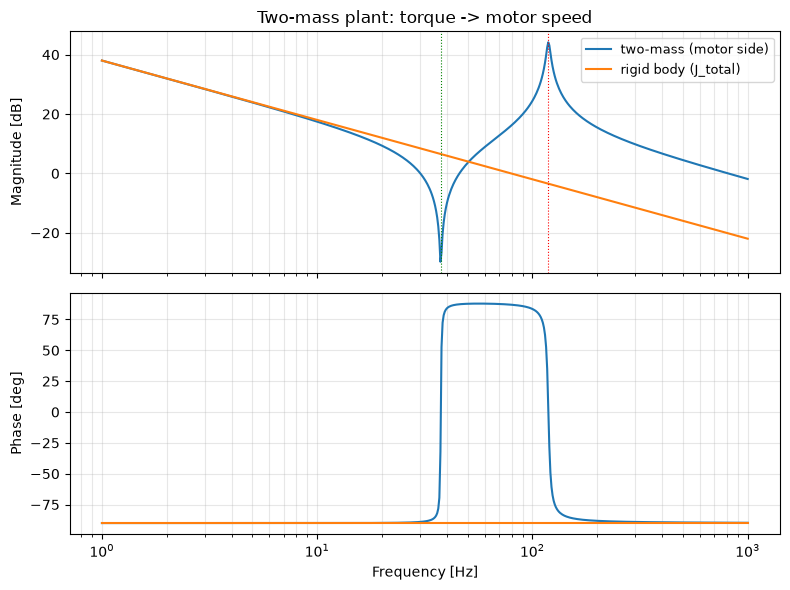

400 Hz 處增益抬升:20.7 dB(理論 20·log10(1+Jl/Jm) = 20.0 dB)


In [2]:
from scipy import signal

PAR = dict(Jm=2e-4, Jl=1.8e-3, ks=100.0, cs=0.005)
fs = 2000.0
dt = 1 / fs
tm0 = TwoMassPlant(**PAR)
f_res, f_anti = tm0.resonance_hz, tm0.antiresonance_hz
print(f'反共振 {f_anti:.1f} Hz | 共振 {f_res:.1f} Hz | 慣量比 Jl/Jm = {PAR["Jl"]/PAR["Jm"]:.0f}')

# 解析 two-mass 轉移函數(轉矩 -> 馬達速度)
Jm, Jl, ks, cs = PAR['Jm'], PAR['Jl'], PAR['ks'], PAR['cs']
P_2mass = ct.tf([Jl, cs, ks], [Jm * Jl, (Jm + Jl) * cs, (Jm + Jl) * ks, 0.0])
P_rigid = ct.tf([1], [Jm + Jl, 0])

fig, (axm, axp) = bode_compare([
    ('two-mass (motor side)', P_2mass),
    ('rigid body (J_total)', P_rigid),
], f_hz=np.logspace(0, 3, 600), title='Two-mass plant: torque -> motor speed')
axm.axvline(f_anti, color='g', ls=':', lw=0.8)
axm.axvline(f_res, color='r', ls=':', lw=0.8)
plt.show()

# 共振之上增益抬升 = 20*log10(1 + Jl/Jm) ≈ 20 dB
hi = frf_of_system(P_2mass, [400.0])['mag_db'][0]
hi_rigid = frf_of_system(P_rigid, [400.0])['mag_db'][0]
lift_db = float(hi - hi_rigid)
print(f'400 Hz 處增益抬升:{lift_db:.1f} dB(理論 20·log10(1+Jl/Jm) = {20*np.log10(1+Jl/Jm):.1f} dB)')

**關鍵觀察**:共振之上,負載「脫鉤」了,馬達只看到自己的慣量 $J_m$
—— 迴路增益比剛體模型預期**高 10 倍(+20 dB)**。
交越頻率因此被推到高頻延遲的死亡區,這就是共振限制增益的機制。

## 增益上限掃描

同一把尺量所有情況:kp 往上掃,直到響應發散或殘留振盪。

In [3]:
class Biquad:
    def __init__(self, b, a):
        self.b, self.a = b, a
        self.x1 = self.x2 = self.y1 = self.y2 = 0.0
    def step(self, x):
        y = (self.b[0] * x + self.b[1] * self.x1 + self.b[2] * self.x2
             - self.a[1] * self.y1 - self.a[2] * self.y2)
        self.x2, self.x1 = self.x1, x
        self.y2, self.y1 = self.y1, y
        return y

class OnePole:
    def __init__(self, fc_hz, dt):
        a = 2 * np.pi * fc_hz * dt
        self.alpha, self.y = a / (1 + a), 0.0
    def step(self, x):
        self.y += self.alpha * (x - self.y)
        return self.y

n = int(2.0 / dt)

def run_loop(kp, par=None, filt=None, rigid=False, ki=5.0):
    """回傳 (是否穩定, 馬達速度波形)。穩定 = 不發散且尾段殘留振盪 < 0.05。"""
    if rigid:
        plant = MotorPlant(J=2e-3, b=0.0, dt=dt)
        get = lambda: plant.w
    else:
        plant = TwoMassPlant(**par, dt=dt)
        get = lambda: plant.wm
    c = DiscretePID(kp=kp, ki=ki, dt=dt)
    dly = Delay(1)
    if filt == 'notch':
        f0 = TwoMassPlant(**par).resonance_hz
        flt = Biquad(*signal.iirnotch(f0 / (fs / 2), 2))
    elif filt == 'lpf':
        flt = OnePole(60, dt)
    else:
        flt = None
    y = np.empty(n)
    for k in range(n):
        y[k] = get()
        meas = flt.step(y[k]) if flt else y[k]
        plant.step(dly.step(c.step(1.0 - meas)))
        if not np.isfinite(get()) or abs(get()) > 1e4:
            return False, y[:k + 1]
    tail = y[int(0.8 * n):]
    return (tail.max() - tail.min()) < 0.05, y

def kp_max(**kw):
    last = 0.0
    for kp in np.concatenate([np.arange(0.05, 1.01, 0.05), np.arange(1.1, 4.01, 0.1)]):
        ok, _ = run_loop(round(float(kp), 2), **kw)
        if ok:
            last = round(float(kp), 2)
        else:
            break
    return last

BAL = dict(Jm=1e-3, Jl=1e-3, ks=100.0, cs=0.005)    # 同總慣量、慣量比 1:1
table = {
    'rigid body (dream)':        kp_max(rigid=True),
    'two-mass, no cure':         kp_max(par=PAR),
    'two-mass + LPF 60 Hz':      kp_max(par=PAR, filt='lpf'),
    'two-mass + notch @res':     kp_max(par=PAR, filt='notch'),
    'two-mass, Jl/Jm=1 (mech!)': kp_max(par=BAL),
}
print(f"{'configuration':<28} kp_max")
for name, v in table.items():
    print(f'{name:<28} {v:>6.2f}')

configuration                kp_max
rigid body (dream)             3.90
two-mass, no cure              0.30
two-mass + LPF 60 Hz           0.10
two-mass + notch @res          0.35
two-mass, Jl/Jm=1 (mech!)      1.90


## 讀表(每台機器的數字不同,機制永遠相同)

- **共振把可用增益砍了一個數量級**:剛體能到 ~3.9,two-mass 只剩 ~0.3。
- **notch 只小補**:它壓掉共振峰,但救不了「共振之上增益抬升」的第二交越。
- **LPF 更糟**:60 Hz 低通吃掉交越處相位,比不濾還差 —— 濾波器不是萬靈丹。
- **機構才是王道**:慣量比 1:1(加飛輪/換傳動比)把上限拉回 6 倍。
  Ellis 的名言:*最好的控制器修不好爛機構。*

## 失穩時,振盪在哪個頻率?

振盪頻率 348 Hz;第二交越預測 kp/(2π·Jm) = 318 Hz;共振 119 Hz


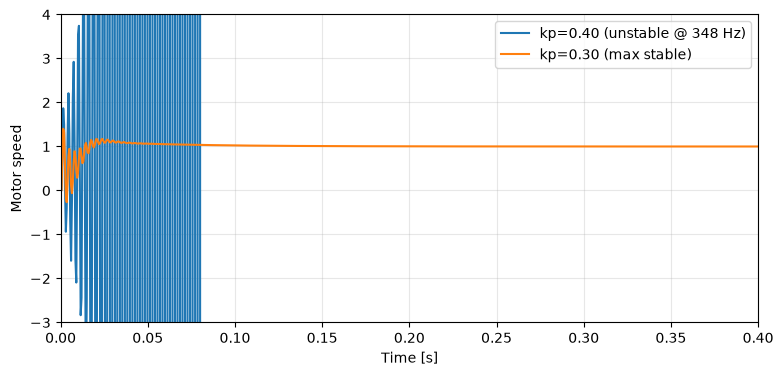

In [4]:
kp_unstable = table['two-mass, no cure'] + 0.1
ok, y_osc = run_loop(kp_unstable, par=PAR)
seg = y_osc[-min(2048, len(y_osc)):]
seg = seg - np.mean(seg)
F = np.fft.rfft(seg * np.hanning(len(seg)))
fr = np.fft.rfftfreq(len(seg), dt)
f_osc = float(fr[np.argmax(np.abs(F))])
f_pred = kp_unstable / (2 * np.pi * PAR['Jm'])      # 第二交越:kp / (2π·Jm)
print(f'振盪頻率 {f_osc:.0f} Hz;第二交越預測 kp/(2π·Jm) = {f_pred:.0f} Hz;共振 {f_res:.0f} Hz')

ok2, y_ok = run_loop(table['two-mass, no cure'], par=PAR)
t_plot = np.arange(n) * dt
plt.figure(figsize=(9, 4))
plt.plot(np.arange(len(y_osc)) * dt, y_osc, label=f'kp={kp_unstable:.2f} (unstable @ {f_osc:.0f} Hz)')
plt.plot(t_plot, y_ok, label=f'kp={table["two-mass, no cure"]:.2f} (max stable)')
plt.xlim(0, 0.4); plt.ylim(-3, 4)
plt.xlabel('Time [s]'); plt.ylabel('Motor speed'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [5]:
# ✅ 驗證
assert abs(lift_db - 20 * np.log10(1 + Jl / Jm)) < 2       # 增益抬升 = 慣量比
assert table['rigid body (dream)'] > 3
assert table['two-mass, no cure'] <= table['rigid body (dream)'] / 5   # 共振砍增益 ≥5 倍
assert table['two-mass + notch @res'] >= table['two-mass, no cure']
assert table['two-mass + LPF 60 Hz'] <= table['two-mass, no cure']     # LPF 在此機台失敗
assert table['two-mass, Jl/Jm=1 (mech!)'] >= 4 * table['two-mass, no cure']
assert abs(f_osc - f_pred) / f_pred < 0.35                 # 振盪頻率 ≈ 第二交越
print('Ch16 驗證通過 ✅')

Ch16 驗證通過 ✅


## 練習
1. 用第 13 章的 DSA 流程量測本章機台的 FRF,確認共振/反共振頻率。
2. 把 ks 加 10 倍(剛性聯軸器),共振頻率變多少?kp_max 呢?(注意:別忘了它會撞上取樣延遲)
3. 在**負載端**放編碼器回授速度(non-collocated),kp_max 掉到多少?為什麼更糟?
4. 雙編碼器方案:馬達端回授速度迴路、負載端回授位置迴路 —— 架構畫出來,並解釋為什麼工業界這麼做。